# TextCNN + Metadata

This notebook trains and evaluates the TextCNN model with metadata features (genre, playtime tier, review length tier).

In [28]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler
from torch.optim.lr_scheduler import ReduceLROnPlateau

import fasttext
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm import tqdm
import json

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

with open("/kaggle/input/results/textcnn_metadata_optuna_best_params.json", "r") as f:
    best_params = json.load(f)

# Configuration
RANDOM_SEED = 42
N_FOLDS = 5
BATCH_SIZE = best_params['best_params']["batch_size"]
MAX_LENGTH = 256
EMBEDDING_DIM = 200
N_FILTERS = best_params['best_params']["n_filters"]
FILTER_SIZES = [int(x) for x in best_params['best_params']["filter_sizes"].split(",")]
HIDDEN_DIM = best_params['best_params']["hidden_dim"]
DROPOUT = best_params['best_params']["dropout"]
LEARNING_RATE = best_params['best_params']["learning_rate"]
WEIGHT_DECAY = best_params['best_params']["weight_decay"]
NUM_EPOCHS = 15
PATIENCE = 3
METADATA_EMBED_DIM = best_params['best_params']["metadata_embed_dim"]

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print(f"Device: {device}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
CUDA available: True
GPU: Tesla P100-PCIE-16GB


## 1. Load Data and Encode Metadata

In [29]:
# Load train and test data
DATA_DIR = Path('/kaggle/input/steam-review')
MODEL_DIR = Path('/kaggle/input/fasttext-steam-200/other/default/1')

train_df = pd.read_csv(DATA_DIR / 'train.csv')
test_df = pd.read_csv(DATA_DIR / 'test.csv')

print(f"Train set: {len(train_df):,} reviews")
print(f"Test set: {len(test_df):,} reviews")
print("\nTrain sentiment distribution:")
print(train_df['voted_up'].value_counts(normalize=True))

Train set: 34,481 reviews
Test set: 6,086 reviews

Train sentiment distribution:
voted_up
True     0.500044
False    0.499956
Name: proportion, dtype: float64


In [30]:
# Encode categorical metadata
genre_encoder = LabelEncoder()
playtime_tier_encoder = LabelEncoder()
length_tier_encoder = LabelEncoder()

genre_encoder.fit(train_df['primary_genre'])
playtime_tier_encoder.fit(train_df['playtime_tier'])
length_tier_encoder.fit(train_df['length_tier'])

# Transform
train_df['genre_id'] = genre_encoder.transform(train_df['primary_genre'])
train_df['playtime_tier_id'] = playtime_tier_encoder.transform(train_df['playtime_tier'])
train_df['length_tier_id'] = length_tier_encoder.transform(train_df['length_tier'])

test_df['genre_id'] = genre_encoder.transform(test_df['primary_genre'])
test_df['playtime_tier_id'] = playtime_tier_encoder.transform(test_df['playtime_tier'])
test_df['length_tier_id'] = length_tier_encoder.transform(test_df['length_tier'])

NUM_GENRES = len(genre_encoder.classes_)
NUM_PLAYTIME_TIERS = len(playtime_tier_encoder.classes_)
NUM_LENGTH_TIERS = len(length_tier_encoder.classes_)

print(f"Genre categories ({NUM_GENRES}): {list(genre_encoder.classes_)}")
print(f"Playtime tier categories ({NUM_PLAYTIME_TIERS}): {list(playtime_tier_encoder.classes_)}")
print(f"Length tier categories ({NUM_LENGTH_TIERS}): {list(length_tier_encoder.classes_)}")

Genre categories (12): ['action_fps', 'anime', 'casual', 'exploration_open_world', 'hidden_object', 'horror', 'puzzle_matching', 'rpg_action', 'science_fiction', 'sports', 'survival', 'visual_novel']
Playtime tier categories (4): ['long', 'medium', 'short', 'unknown']
Length tier categories (3): ['long', 'medium', 'short']


In [31]:
# Prepare features and labels
X_train = train_df['processed_text'].fillna('').values
y_train = train_df['voted_up'].astype(int).values

genre_ids_train = train_df['genre_id'].values
playtime_tier_ids_train = train_df['playtime_tier_id'].values
length_tier_ids_train = train_df['length_tier_id'].values

X_test = test_df['processed_text'].fillna('').values
y_test = test_df['voted_up'].astype(int).values

genre_ids_test = test_df['genre_id'].values
playtime_tier_ids_test = test_df['playtime_tier_id'].values
length_tier_ids_test = test_df['length_tier_id'].values

stratify_key = train_df['voted_up'].astype(str) + '_' + train_df['primary_genre'].astype(str)

print(f"Features: {len(X_train):,} train, {len(X_test):,} test")

Features: 34,481 train, 6,086 test


## 2. Load FastText Embeddings

In [32]:
print("Loading FastText model...")
ft_model = fasttext.load_model(str(MODEL_DIR / 'steam_fasttext.bin'))
print(f"FastText loaded: {ft_model.get_dimension()}-dimensional embeddings")
print(f"Vocabulary size: {len(ft_model.words):,}")

Loading FastText model...
FastText loaded: 200-dimensional embeddings
Vocabulary size: 32,313


## 3. Dataset with Metadata

In [33]:
class SteamReviewDatasetWithMetadata(Dataset):
    def __init__(self, texts, labels, genre_ids, playtime_tier_ids, length_tier_ids,
                 ft_model, max_length=256):
        self.texts = texts
        self.labels = labels
        self.genre_ids = genre_ids
        self.playtime_tier_ids = playtime_tier_ids
        self.length_tier_ids = length_tier_ids
        self.ft_model = ft_model
        self.max_length = max_length
        self.embedding_dim = ft_model.get_dimension()
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = self.texts[idx]
        tokens = text.split()[:self.max_length]
        
        embeddings = np.zeros((self.max_length, self.embedding_dim), dtype=np.float32)
        for i, token in enumerate(tokens):
            embeddings[i] = self.ft_model.get_word_vector(token)
        
        mask = np.zeros(self.max_length, dtype=np.float32)
        mask[:len(tokens)] = 1.0
        
        return {
            'embeddings': torch.tensor(embeddings, dtype=torch.float32),
            'mask': torch.tensor(mask, dtype=torch.float32),
            'label': torch.tensor(self.labels[idx], dtype=torch.float32),
            'genre_id': torch.tensor(self.genre_ids[idx], dtype=torch.long),
            'playtime_tier_id': torch.tensor(self.playtime_tier_ids[idx], dtype=torch.long),
            'length_tier_id': torch.tensor(self.length_tier_ids[idx], dtype=torch.long)
        }


def create_dataloader_with_metadata(texts, labels, genre_ids, playtime_tier_ids, 
                                     length_tier_ids, ft_model, batch_size, shuffle=True):
    dataset = SteamReviewDatasetWithMetadata(
        texts, labels, genre_ids, playtime_tier_ids, length_tier_ids,
        ft_model, MAX_LENGTH
    )
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=4,
        pin_memory=True
    )

## 4. Model Architecture

In [34]:
class TextCNNWithMetadata(nn.Module):
    """TextCNN + Metadata for sentiment classification."""
    
    def __init__(self, embedding_dim=200, n_filters=128, filter_sizes=[3, 4, 5],
                 hidden_dim=128, dropout=0.3,
                 num_genres=12, num_playtime_tiers=4, num_length_tiers=3,
                 metadata_embed_dim=16):
        super().__init__()
        
        # CNN layers
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=embedding_dim, 
                      out_channels=n_filters,
                      kernel_size=fs) 
            for fs in filter_sizes
        ])
        
        # Metadata embeddings
        self.genre_embed = nn.Embedding(num_genres, metadata_embed_dim)
        self.playtime_tier_embed = nn.Embedding(num_playtime_tiers, metadata_embed_dim)
        self.length_tier_embed = nn.Embedding(num_length_tiers, metadata_embed_dim)
        
        cnn_output_dim = n_filters * len(filter_sizes)
        combined_dim = cnn_output_dim + metadata_embed_dim * 3
        
        self.classifier = nn.Sequential(
            nn.Linear(combined_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, embeddings, mask, genre_ids, playtime_tier_ids, length_tier_ids):
        masked_embeddings = embeddings * mask.unsqueeze(-1)
        x = masked_embeddings.permute(0, 2, 1)
        
        conved = [F.relu(conv(x)) for conv in self.convs]
        pooled = [F.max_pool1d(c, c.shape[2]).squeeze(2) for c in conved]
        text_features = torch.cat(pooled, dim=1)
        
        genre_emb = self.genre_embed(genre_ids)
        playtime_emb = self.playtime_tier_embed(playtime_tier_ids)
        length_emb = self.length_tier_embed(length_tier_ids)
        
        combined = torch.cat([text_features, genre_emb, playtime_emb, length_emb], dim=-1)
        return self.classifier(combined)

In [35]:
# Instantiate model
model = TextCNNWithMetadata(
    embedding_dim=EMBEDDING_DIM, n_filters=N_FILTERS, filter_sizes=FILTER_SIZES,
    hidden_dim=HIDDEN_DIM, dropout=DROPOUT,
    num_genres=NUM_GENRES, num_playtime_tiers=NUM_PLAYTIME_TIERS,
    num_length_tiers=NUM_LENGTH_TIERS, metadata_embed_dim=METADATA_EMBED_DIM
)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

TextCNNWithMetadata(
  (convs): ModuleList(
    (0): Conv1d(200, 256, kernel_size=(3,), stride=(1,))
    (1): Conv1d(200, 256, kernel_size=(4,), stride=(1,))
    (2): Conv1d(200, 256, kernel_size=(5,), stride=(1,))
  )
  (genre_embed): Embedding(12, 32)
  (playtime_tier_embed): Embedding(4, 32)
  (length_tier_embed): Embedding(3, 32)
  (classifier): Sequential(
    (0): Linear(in_features=864, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.32699416540205284, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)

Total parameters: 671,201


## 5. Training Functions

In [36]:
def train_epoch(model, dataloader, optimizer, criterion, scaler, device):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []
    
    for batch in tqdm(dataloader, desc='Training', leave=False):
        embeddings = batch['embeddings'].to(device)
        mask = batch['mask'].to(device)
        labels = batch['label'].to(device)
        genre_ids = batch['genre_id'].to(device)
        playtime_tier_ids = batch['playtime_tier_id'].to(device)
        length_tier_ids = batch['length_tier_id'].to(device)
        
        optimizer.zero_grad()
        
        with autocast(device_type=device.type):
            logits = model(embeddings, mask, genre_ids, playtime_tier_ids, length_tier_ids).squeeze(-1)
            loss = criterion(logits, labels)
        
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        
        total_loss += loss.item()
        preds = (torch.sigmoid(logits) > 0.5).float()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    return total_loss / len(dataloader), accuracy_score(all_labels, all_preds)


def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Evaluating', leave=False):
            embeddings = batch['embeddings'].to(device)
            mask = batch['mask'].to(device)
            labels = batch['label'].to(device)
            genre_ids = batch['genre_id'].to(device)
            playtime_tier_ids = batch['playtime_tier_id'].to(device)
            length_tier_ids = batch['length_tier_id'].to(device)
            
            with autocast(device_type=device.type):
                logits = model(embeddings, mask, genre_ids, playtime_tier_ids, length_tier_ids).squeeze(-1)
                loss = criterion(logits, labels)
            
            total_loss += loss.item()
            preds = (torch.sigmoid(logits) > 0.5).float()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    
    return avg_loss, accuracy, precision, recall, f1, all_preds, all_labels

## 6. K-Fold Cross-Validation

In [ ]:
print(f"Running {N_FOLDS}-Fold Cross-Validation")

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)

fold_results = []
best_epochs_per_fold = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, stratify_key)):
    print(f"\nFold {fold + 1}/{N_FOLDS}")
    
    X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
    y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]
    genre_fold_train, genre_fold_val = genre_ids_train[train_idx], genre_ids_train[val_idx]
    playtime_fold_train, playtime_fold_val = playtime_tier_ids_train[train_idx], playtime_tier_ids_train[val_idx]
    length_fold_train, length_fold_val = length_tier_ids_train[train_idx], length_tier_ids_train[val_idx]
    
    train_loader = create_dataloader_with_metadata(
        X_fold_train, y_fold_train, genre_fold_train, playtime_fold_train, length_fold_train,
        ft_model, BATCH_SIZE, shuffle=True
    )
    val_loader = create_dataloader_with_metadata(
        X_fold_val, y_fold_val, genre_fold_val, playtime_fold_val, length_fold_val,
        ft_model, BATCH_SIZE, shuffle=False
    )
    
    model = TextCNNWithMetadata(
        embedding_dim=EMBEDDING_DIM, n_filters=N_FILTERS, filter_sizes=FILTER_SIZES,
        hidden_dim=HIDDEN_DIM, dropout=DROPOUT,
        num_genres=NUM_GENRES, num_playtime_tiers=NUM_PLAYTIME_TIERS,
        num_length_tiers=NUM_LENGTH_TIERS, metadata_embed_dim=METADATA_EMBED_DIM
    ).to(device)
    
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=1)
    criterion = nn.BCEWithLogitsLoss()
    scaler = GradScaler()
    
    best_val_f1 = 0
    best_epoch = 0
    patience_counter = 0
    best_metrics = None
    
    for epoch in range(NUM_EPOCHS):
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, scaler, device)
        val_loss, val_acc, val_prec, val_rec, val_f1, _, _ = evaluate(model, val_loader, criterion, device)
        
        scheduler.step(val_f1)
        print(f"Epoch {epoch + 1}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}, Val F1={val_f1:.4f}")
        
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_epoch = epoch + 1
            best_metrics = {'accuracy': val_acc, 'precision': val_prec, 'recall': val_rec, 'f1': val_f1}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"Early stopping at epoch {epoch + 1}")
                break
    
    fold_results.append(best_metrics)
    best_epochs_per_fold.append(best_epoch)
    print(f"Fold {fold + 1} Best: Accuracy={best_metrics['accuracy']:.4f}, F1={best_metrics['f1']:.4f}")

Running 5-Fold Cross-Validation

Fold 1/5


Epoch 1: Train Loss=0.3966, Val Loss=0.3002, Val F1=0.8713


Epoch 2: Train Loss=0.2500, Val Loss=0.2795, Val F1=0.8823


Epoch 3: Train Loss=0.1719, Val Loss=0.3416, Val F1=0.8507


Epoch 4: Train Loss=0.0981, Val Loss=0.3268, Val F1=0.8840


...

Epoch 2: Train Loss=0.2558, Val Loss=0.2877, Val F1=0.8721


Epoch 3: Train Loss=0.1715, Val Loss=0.2849, Val F1=0.8901


Epoch 4: Train Loss=0.0977, Val Loss=0.3777, Val F1=0.8620


Epoch 5: Train Loss=0.0383, Val Loss=0.3866, Val F1=0.8817


Epoch 6: Train Loss=0.0105, Val Loss=0.3940, Val F1=0.8863
Early stopping at epoch 6
Fold 5 Best: Accuracy=0.8876, F1=0.8901


In [ ]:
print("\nTraining model for learning curve visualization...")

from sklearn.model_selection import train_test_split

X_train_plot, X_val_plot, y_train_plot, y_val_plot, \
    genre_train_plot, genre_val_plot, \
    playtime_train_plot, playtime_val_plot, \
    length_train_plot, length_val_plot = train_test_split(
        X_train, y_train, genre_ids_train, playtime_tier_ids_train, length_tier_ids_train,
        test_size=0.1, random_state=RANDOM_SEED, stratify=y_train
    )

train_loader_plot = create_dataloader_with_metadata(
    X_train_plot, y_train_plot, genre_train_plot, playtime_train_plot, length_train_plot,
    ft_model, BATCH_SIZE, shuffle=True
)
val_loader_plot = create_dataloader_with_metadata(
    X_val_plot, y_val_plot, genre_val_plot, playtime_val_plot, length_val_plot,
    ft_model, BATCH_SIZE, shuffle=False
)

plot_model = TextCNNWithMetadata(
    embedding_dim=EMBEDDING_DIM, n_filters=N_FILTERS, filter_sizes=FILTER_SIZES,
    hidden_dim=HIDDEN_DIM, dropout=DROPOUT,
    num_genres=NUM_GENRES, num_playtime_tiers=NUM_PLAYTIME_TIERS,
    num_length_tiers=NUM_LENGTH_TIERS, metadata_embed_dim=METADATA_EMBED_DIM
).to(device)

optimizer = torch.optim.AdamW(plot_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
criterion = nn.BCEWithLogitsLoss()
scaler = GradScaler()

train_losses = []
val_losses = []

for epoch in range(NUM_EPOCHS):
    train_loss, _ = train_epoch(plot_model, train_loader_plot, optimizer, criterion, scaler, device)
    val_loss, _, _, _, _, _, _ = evaluate(plot_model, val_loader_plot, criterion, device)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    print(f"Epoch {epoch + 1}/{NUM_EPOCHS}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}")

# Plot Learning Curve
plt.figure(figsize=(10, 6))
epochs_range = range(1, len(train_losses) + 1)
plt.plot(epochs_range, train_losses, 'b-o', label='Train Loss', linewidth=2, markersize=6)
plt.plot(epochs_range, val_losses, 'r-o', label='Validation Loss', linewidth=2, markersize=6)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (BCE)', fontsize=12)
plt.title('Learning Curve - TextCNN+Metadata', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(epochs_range)
plt.tight_layout()

# Save the plot
plt.savefig('learning_curve_textcnn_metadata.png', dpi=300, bbox_inches='tight')
print("\nLearning curve saved to learning_curve_textcnn_metadata.png")
plt.show()

# Save loss history to JSON
loss_history = {
    'model': 'TextCNN+Metadata',
    'epochs': list(epochs_range),
    'train_losses': train_losses,
    'val_losses': val_losses
}
with open('textcnn_metadata_loss_history.json', 'w') as f:
    json.dump(loss_history, f, indent=2)
print("Loss history saved to textcnn_metadata_loss_history.json")


Training model for learning curve visualization...


Epoch 1/7: Train Loss=0.3973, Val Loss=0.3198


Epoch 2/7: Train Loss=0.2585, Val Loss=0.2789


Epoch 3/7: Train Loss=0.1831, Val Loss=0.2891


Epoch 4/7: Train Loss=0.1156, Val Loss=0.2786


Epoch 5/7: Train Loss=0.0514, Val Loss=0.3564


Epoch 6/7: Train Loss=0.0202, Val Loss=0.3668


Epoch 7/7: Train Loss=0.0070, Val Loss=0.3724

Learning curve saved to learning_curve_textcnn_metadata.png


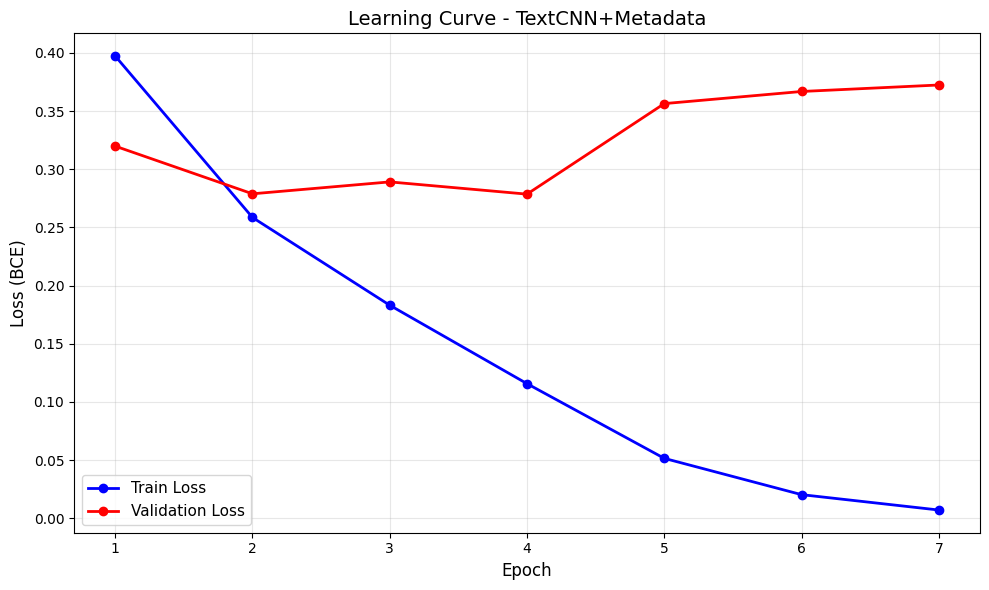

Loss history saved to textcnn_metadata_loss_history.json


In [ ]:
print("\nTraining model for learning curve visualization...")

from sklearn.model_selection import train_test_split

X_train_plot, X_val_plot, y_train_plot, y_val_plot, \
    genre_train_plot, genre_val_plot, \
    playtime_train_plot, playtime_val_plot, \
    length_train_plot, length_val_plot = train_test_split(
        X_train, y_train, genre_ids_train, playtime_tier_ids_train, length_tier_ids_train,
        test_size=0.1, random_state=RANDOM_SEED, stratify=y_train
    )

train_loader_plot = create_dataloader_with_metadata(
    X_train_plot, y_train_plot, genre_train_plot, playtime_train_plot, length_train_plot,
    ft_model, BATCH_SIZE, shuffle=True
)
val_loader_plot = create_dataloader_with_metadata(
    X_val_plot, y_val_plot, genre_val_plot, playtime_val_plot, length_val_plot,
    ft_model, BATCH_SIZE, shuffle=False
)

plot_model = TextCNNWithMetadata(
    embedding_dim=EMBEDDING_DIM, n_filters=N_FILTERS, filter_sizes=FILTER_SIZES,
    hidden_dim=HIDDEN_DIM, dropout=DROPOUT,
    num_genres=NUM_GENRES, num_playtime_tiers=NUM_PLAYTIME_TIERS,
    num_length_tiers=NUM_LENGTH_TIERS, metadata_embed_dim=METADATA_EMBED_DIM
).to(device)

optimizer = torch.optim.AdamW(plot_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=1)
criterion = nn.BCEWithLogitsLoss()
scaler = GradScaler()

train_losses = []
val_losses = []

early_stopping_epoch = 7 #int(np.median(best_epochs_per_fold)) + PATIENCE

for epoch in range(early_stopping_epoch):
    train_loss, _ = train_epoch(plot_model, train_loader_plot, optimizer, criterion, scaler, device)
    val_loss, _, _, _, _, _, _ = evaluate(plot_model, val_loader_plot, criterion, device)
    
    scheduler.step(val_loss)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    print(f"Epoch {epoch + 1}/{early_stopping_epoch}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}")

# Plot Learning Curve
plt.figure(figsize=(10, 6))
epochs_range = range(1, len(train_losses) + 1)
plt.plot(epochs_range, train_losses, 'b-o', label='Train Loss', linewidth=2, markersize=6)
plt.plot(epochs_range, val_losses, 'r-o', label='Validation Loss', linewidth=2, markersize=6)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (BCE)', fontsize=12)
plt.title('Learning Curve - TextCNN+Metadata', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(epochs_range)
plt.tight_layout()

# Save the plot
plt.savefig('learning_curve_textcnn_metadata.png', dpi=300, bbox_inches='tight')
print("\nLearning curve saved to learning_curve_textcnn_metadata.png")
plt.show()

# Save loss history to JSON
loss_history = {
    'model': 'TextCNN+Metadata',
    'epochs': list(epochs_range),
    'train_losses': train_losses,
    'val_losses': val_losses
}
with open('textcnn_metadata_loss_history.json', 'w') as f:
    json.dump(loss_history, f, indent=2)
print("Loss history saved to textcnn_metadata_loss_history.json")

In [38]:
# CV Summary
print("TextCNN+Metadata Cross-Validation Results")
for metric in ['accuracy', 'precision', 'recall', 'f1']:
    values = [r[metric] for r in fold_results]
    print(f"{metric.capitalize()}: {np.mean(values):.4f} ± {np.std(values):.4f}")

print(f"\nBest epochs per fold: {best_epochs_per_fold}")
optimal_epochs = int(np.median(best_epochs_per_fold))
print(f"Optimal epochs for final training: {optimal_epochs}")

TextCNN+Metadata Cross-Validation Results
Accuracy: 0.8885 ± 0.0036
Precision: 0.8809 ± 0.0095
Recall: 0.8986 ± 0.0079
F1: 0.8896 ± 0.0030

Best epochs per fold: [10, 2, 5, 7, 3]
Optimal epochs for final training: 5


## 7. Final Training and Test Evaluation

In [39]:
print("\nTraining final model on full training data...")

full_train_loader = create_dataloader_with_metadata(
    X_train, y_train, genre_ids_train, playtime_tier_ids_train, length_tier_ids_train,
    ft_model, BATCH_SIZE, shuffle=True
)

test_loader = create_dataloader_with_metadata(
    X_test, y_test, genre_ids_test, playtime_tier_ids_test, length_tier_ids_test,
    ft_model, BATCH_SIZE, shuffle=False
)

final_model = TextCNNWithMetadata(
    embedding_dim=EMBEDDING_DIM, n_filters=N_FILTERS, filter_sizes=FILTER_SIZES,
    hidden_dim=HIDDEN_DIM, dropout=DROPOUT,
    num_genres=NUM_GENRES, num_playtime_tiers=NUM_PLAYTIME_TIERS,
    num_length_tiers=NUM_LENGTH_TIERS, metadata_embed_dim=METADATA_EMBED_DIM
).to(device)

optimizer = torch.optim.AdamW(final_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
criterion = nn.BCEWithLogitsLoss()
scaler = GradScaler()

for epoch in range(optimal_epochs):
    train_loss, train_acc = train_epoch(final_model, full_train_loader, optimizer, criterion, scaler, device)
    print(f"Epoch {epoch + 1}/{optimal_epochs}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}")


Training final model on full training data...


Epoch 1/5: Train Loss=0.3796, Train Acc=0.8272


Epoch 2/5: Train Loss=0.2479, Train Acc=0.9001


Epoch 3/5: Train Loss=0.1704, Train Acc=0.9379


Epoch 4/5: Train Loss=0.0833, Train Acc=0.9738


Epoch 5/5: Train Loss=0.0335, Train Acc=0.9913


In [40]:
# Test evaluation
print("\nEvaluating on test set...")

test_loss, test_acc, test_prec, test_rec, test_f1, test_preds, test_labels = evaluate(
    final_model, test_loader, criterion, device
)

print("TEST SET RESULTS - TextCNN+Metadata")
print(f"Accuracy:  {test_acc:.4f}")
print(f"Precision: {test_prec:.4f}")
print(f"Recall:    {test_rec:.4f}")
print(f"F1 Score:  {test_f1:.4f}")

print("\nClassification Report:")
print(classification_report(test_labels, test_preds, target_names=['Negative', 'Positive']))


Evaluating on test set...


TEST SET RESULTS - TextCNN+Metadata
Accuracy:  0.8776
Precision: 0.8499
Recall:    0.9172
F1 Score:  0.8823

Classification Report:
              precision    recall  f1-score   support

    Negative       0.91      0.84      0.87      3043
    Positive       0.85      0.92      0.88      3043

    accuracy                           0.88      6086
   macro avg       0.88      0.88      0.88      6086
weighted avg       0.88      0.88      0.88      6086



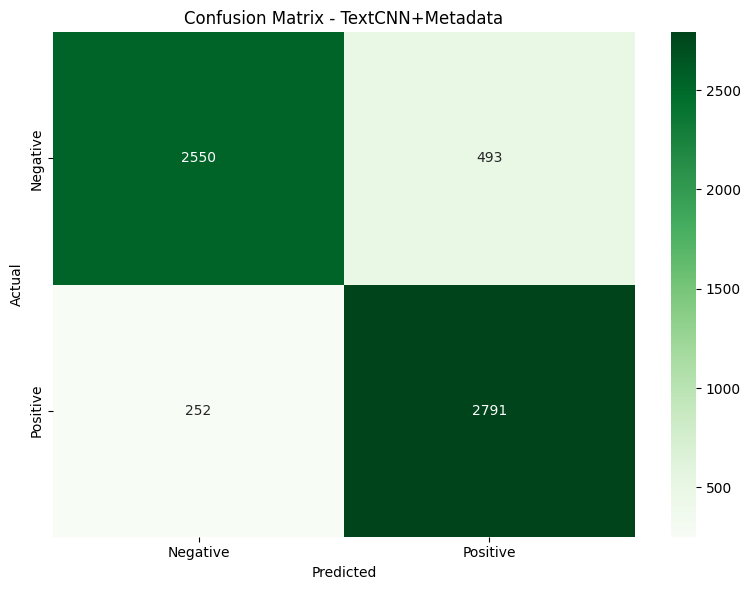

In [41]:
# Confusion Matrix
cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - TextCNN+Metadata')
plt.tight_layout()
plt.show()

## 8. Save Results

In [44]:
import json

results = {
    'model_type': 'TextCNN+Metadata',
    'cv_results': {
        'accuracy': {'mean': float(np.mean([r['accuracy'] for r in fold_results])),
                     'std': float(np.std([r['accuracy'] for r in fold_results]))},
        'precision': {'mean': float(np.mean([r['precision'] for r in fold_results])),
                      'std': float(np.std([r['precision'] for r in fold_results]))},
        'recall': {'mean': float(np.mean([r['recall'] for r in fold_results])),
                   'std': float(np.std([r['recall'] for r in fold_results]))},
        'f1': {'mean': float(np.mean([r['f1'] for r in fold_results])),
               'std': float(np.std([r['f1'] for r in fold_results]))}
    },
    'test_results': {
        'accuracy': float(test_acc),
        'precision': float(test_prec),
        'recall': float(test_rec),
        'f1': float(test_f1)
    },
    'optimal_epochs': optimal_epochs,
    'hyperparameters': {
        'batch_size': BATCH_SIZE,
        'n_filters': N_FILTERS,
        'filter_sizes': FILTER_SIZES,
        'hidden_dim': HIDDEN_DIM,
        'dropout': DROPOUT,
        'learning_rate': LEARNING_RATE,
        'metadata_embed_dim': METADATA_EMBED_DIM
    }
}

# Save results
results_path = 'textcnn_metadata_results.json'
with open(results_path, 'w') as f:
    json.dump(results, f, indent=2)

print(f"Results saved to {results_path}")

Results saved to textcnn_metadata_results.json


In [45]:
# Save the trained model
torch.save({
    'model_state_dict': final_model.state_dict(),
    'config': {
        'embedding_dim': EMBEDDING_DIM,
        'n_filters': N_FILTERS,
        'filter_sizes': FILTER_SIZES,
        'hidden_dim': HIDDEN_DIM,
        'dropout': DROPOUT,
        'num_genres': NUM_GENRES,
        'num_playtime_tiers': NUM_PLAYTIME_TIERS,
        'num_length_tiers': NUM_LENGTH_TIERS,
        'metadata_embed_dim': METADATA_EMBED_DIM
    }
}, 'textcnn_metadata.pt')


print("Model saved to textcnn_metadata.pt")

Model saved to textcnn_metadata.pt
